Preliminaries

In [1]:
import importlib
import coupling_utils as cl
import element
import numpy as np

importlib.reload(cl)
importlib.reload(element)

from element import get_matrix_element

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import pandas as pd
import gc

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [4]:
m_t = 173

Checks

In [5]:
N = 10
X = torch.rand(N, 5, device=device, dtype=torch.float64)
(P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
print(P.shape, P1.shape, P2.shape, P3.shape, jac_map.shape)


torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10])


In [6]:
element.check_conservation(P1, P2, P3, m_t, tol=1e-10)

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed


In [7]:
me_values = element.batch_element_eval(P, P1, P2, P3, device=device, dtype=np.float64) * jac_map
print(me_values)

tensor([1.5880e+05, 1.2721e+06, 1.0885e+07, 5.4552e+06, 6.1510e+04, 1.5007e+04,
        2.4151e+03, 9.0500e+04, 1.4622e+06, 1.3255e+05], device='cuda:0',
       dtype=torch.float64)


Train flow

In [8]:
A_dims = [torch.tensor([1, 2, 3, 4]),
          torch.tensor([0, 2, 3, 4]),
          torch.tensor([0, 1, 3, 4]),
          torch.tensor([0, 1, 2, 3])]


B_dims = [torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([2]),
          torch.tensor([3]),
          torch.tensor([4])]

In [61]:
final_loss, loss_values, flow = cl.train_loop_decay(
    D=5,
    layer_type=cl.pwq_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=16,
    N=8000,
    epochs=6500,
    lr=3e-5,
    device=device,
    dtype=np.float64,
    ticker=True
)

Normalisation scale: 18642679.751906928
Epoch: 0 | Loss: 8.82761712e-01
Mean value:  4171194.1764263823
Epoch: 20 | Loss: 9.50842579e-01
Mean value:  4226869.443773244
Epoch: 40 | Loss: 9.73176152e-01
Mean value:  4182329.103805778
Epoch: 60 | Loss: 1.14271859e+00
Mean value:  4637143.3998548165
Epoch: 80 | Loss: 1.04348566e+00
Mean value:  4438619.695985208
Epoch: 100 | Loss: 1.01620128e+00
Mean value:  4405507.95046695
Epoch: 120 | Loss: 9.93674996e-01
Mean value:  4412473.195321234
Epoch: 140 | Loss: 9.20854129e-01
Mean value:  4269260.718319984
Epoch: 160 | Loss: 8.90530837e-01
Mean value:  4158408.5808158848
Epoch: 180 | Loss: 9.91279009e-01
Mean value:  4442772.300628433
Epoch: 200 | Loss: 1.00920572e+00
Mean value:  4394293.0346362265
Epoch: 220 | Loss: 9.60210021e-01
Mean value:  4464512.992128917
Epoch: 240 | Loss: 8.73666011e-01
Mean value:  4114180.5295371
Epoch: 260 | Loss: 9.38445779e-01
Mean value:  4357531.683637129
Epoch: 280 | Loss: 1.03093957e+00
Mean value:  4647220.

Plot loss behaviour

In [62]:
def moving_average(loss_values, window_size=50):
    if loss_values.dim() != 1:
        raise ValueError("loss_values must be 1D")
    if window_size < 1:
        raise ValueError("window_size must be at least 1")

    mov_avg = torch.empty(len(loss_values) - window_size + 1, dtype=loss_values.dtype, device=loss_values.device)
    for i in range(window_size - 1, len(loss_values)):
        mov_avg[i - window_size + 1] = loss_values[i - window_size + 1:i + 1].mean()

    return mov_avg, window_size


mov_avg, window_size = moving_average(loss_values.cpu(), window_size=50)

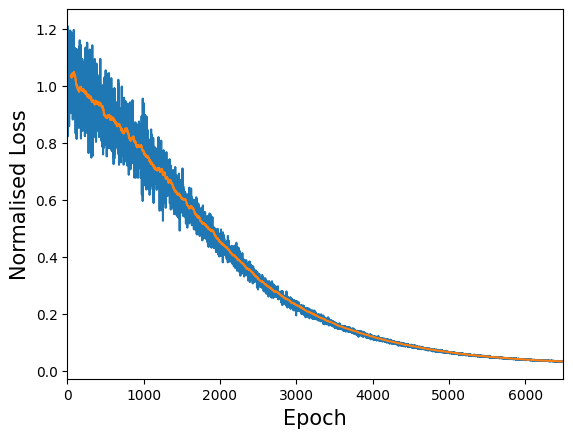

In [63]:
fig, ax = plt.subplots()

epochs_plot = torch.arange(len(loss_values))
epochs_avg = epochs_plot[window_size - 1:]
ax.plot(epochs_plot, loss_values.cpu().numpy(), label='Raw loss')

ax.plot(epochs_avg, mov_avg, label='Moving average')

ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Normalised Loss', fontsize=15)
ax.set_xlim(0, len(loss_values))

plt.show()

Estimate decay width and store parameters in CSV; plot event weights

In [64]:
def flow_decay_width_estimator(flow, B_total, chunk_size):

    flow = flow.to('cpu')
    flow.eval()

    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    with torch.inference_mode():
        # optional one-off diagnostic check
        Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        X_test, _ = flow.inverse(Y_test)
        (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        del Y_test, X_test, P1t, P2t, P3t

        weights_all = []

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            Y = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            X, jac_dets = flow.inverse(Y)

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
            me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

            weights = prefactor * me2_vals * jac_dets * jac_map
            weights_all.append(weights.detach())

            sum_w += weights.sum()
            sum_w2 += (weights * weights).sum()
            n_total += b

            del Y, X, jac_dets, P, P1, P2, P3, jac_map, me2_vals, weights

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)
    weights_all = torch.cat(weights_all)

    return mean, stderr, weights_all

In [65]:
def uniform_decay_width_estimator(B_total, chunk_size):
    
    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    # optional one-off diagnostic check
    Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
    X_test, _ = flow.inverse(Y_test)
    (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
    element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
    del Y_test, X_test, P1t, P2t, P3t
    weights_all = []

    for i in range(0, B_total, chunk_size):
        b = min(chunk_size, B_total - i)

        X = torch.rand((b, 5), device='cpu', dtype=torch.float64)

        (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
        me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

        weights = prefactor * me2_vals * jac_map
        weights_all.append(weights)

        sum_w += weights.sum()
        sum_w2 += (weights * weights).sum()
        n_total += b

        del X, P, P1, P2, P3, jac_map, me2_vals, weights

        if (i // chunk_size) % 10 == 0:
            gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)
    weights_all = torch.cat(weights_all)

    return mean, stderr, weights_all

In [88]:
mean, stderr, weights = flow_decay_width_estimator(flow, B_total=1000000, chunk_size=100000)

print(f"Flow-derived decay width estimate = {mean} ± {stderr}")

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed
Flow-derived decay width estimate = 0.14075373111096762 ± 0.00012464211031998064


In [67]:
print(len(weights))

1000000


In [86]:
mean_u, stderr_u, weights_u = uniform_decay_width_estimator(B_total=1000000, chunk_size=100000)
print(f"Uniform-derived decay width estimate = {mean_u} ± {stderr_u}")

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed
Uniform-derived decay width estimate = 0.16433770681151022 ± 0.0007435758444124797


In [53]:
import pandas as pd
import os

def save_decay_result_pandas(filename, row_dict):
    df_row = pd.DataFrame([row_dict])

    if os.path.exists(filename):
        df_row.to_csv(filename, mode="a", header=False, index=False)
    else:
        df_row.to_csv(filename, index=False)

In [69]:
save_decay_result_pandas(
    "decay_width_results.csv",
    {
        "D": 5,
        "layer_type": "pwq_layer",
        "K": 64,
        "hidden_size": 16,
        "N": 8000,
        "epochs": 6500,
        "lr": 3e-5,
        "dtype": "float64",
        "B": 1000000,
        "final_loss": float(final_loss),
        "decay_width": float(mean),
        "decay_width_error": float(stderr),
    }
)

In [70]:
save_decay_result_pandas(
    "uniform_decay_width_results.csv",
    {
        "D": 5,
        "B": 1000000,
        "decay_width": float(mean_u),
        "decay_width_error": float(stderr_u),
    }
)

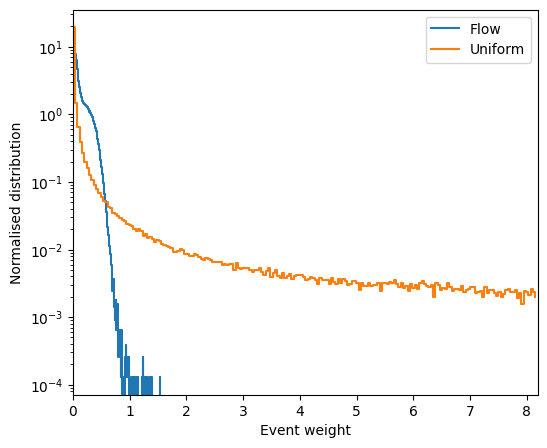

In [89]:
#histogram of weights
bins = 200

counts, bin_edges = np.histogram(weights, bins=bins, density=True)  #get histogram(s)
counts_u, bin_edges_u = np.histogram(weights_u, bins=bins, density=True)

plt.figure(figsize=(6,5))                                           #plot using step style bin edges

plt.step(bin_edges[:-1], counts, where='post', label='Flow')
plt.step(bin_edges_u[:-1], counts_u, where='post', label='Uniform')


plt.xlabel("Event weight")
plt.ylabel("Normalised distribution")
plt.yscale('log')

plt.xlim(0, bin_edges_u[-1])
#plt.xlim(0, 3)
plt.legend()

plt.show()



Unweighting

In [ ]:
def unweight(weights):

    w_max = torch.max(weights)
    w_mean = torch.mean(weights)
    u = torch.rand_like(weights) * w_max

    accept_mask = u < (weights / w_max)
    accepted_weights = weights[accept_mask]

    efficiency_expected = w_mean / w_max
    efficiency_actual = accept_mask.double().mean()
    return accepted_weights, efficiency_actual


In [79]:
x = torch.tensor([1234, 4685349, 4592354230])
y = torch.rand_like(x.float())
print(y)

tensor([0.5170, 0.6739, 0.2919])


In [58]:
accepted_weights, efficiency = unweight(weights)
print(accepted_weights)
print(efficiency)

tensor([0.4822, 0.0018, 0.1724,  ..., 0.1186, 0.3396, 0.8580],
       dtype=torch.float64)
tensor(0.0491, dtype=torch.float64)
